In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('online_retail_II.csv', encoding='utf-8')
print(df.shape)
print(df.head())

(1067371, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 136.6 MB


In [3]:
print(df.isnull().sum())
print("\nEksik değer yüzdeleri:")
print((df.isnull().sum() / len(df) * 100).round(2))

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Eksik değer yüzdeleri:
Invoice         0.00
StockCode       0.00
Description     0.41
Quantity        0.00
InvoiceDate     0.00
Price           0.00
Customer ID    22.77
Country         0.00
dtype: float64


In [4]:
# İadeler genellikle C ile başlar (Cancel)
cancelled = df[df['Invoice'].str.startswith('C')]
print(f"İptal edilen sipariş sayısı: {len(cancelled)}")
print(f"Toplam siparişe oranı: {round(len(cancelled)/len(df)*100, 2)}%")

İptal edilen sipariş sayısı: 19494
Toplam siparişe oranı: 1.83%


In [5]:
# 1. InvoiceDate'i datetime'a çevir
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 2. Customer ID'yi string'e çevir (13085.0 → 13085)
df['Customer ID'] = df['Customer ID'].astype(str).str.replace('.0', '', regex=False)
df['Customer ID'] = df['Customer ID'].replace('nan', np.nan)

# 3. Negatif Quantity → iadeler (C ile başlamayanları temizle)
df_clean = df[~df['Invoice'].str.startswith('C')].copy()

# 4. Price ve Quantity sıfır veya negatif olanları çıkar
df_clean = df_clean[(df_clean['Price'] > 0) & (df_clean['Quantity'] > 0)]

# 5. Toplam gelir sütunu ekle
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

print(f"Temizlenmemiş: {len(df)} satır")
print(f"Temizlenmiş: {len(df_clean)} satır")
print(f"Çıkarılan: {len(df) - len(df_clean)} satır")

Temizlenmemiş: 1067371 satır
Temizlenmiş: 1041670 satır
Çıkarılan: 25701 satır


In [6]:
print(df_clean[['Quantity', 'Price', 'TotalPrice']].describe())

           Quantity         Price    TotalPrice
count  1.041670e+06  1.041670e+06  1.041670e+06
mean   1.096346e+01  4.076683e+00  2.013363e+01
std    1.265150e+02  5.144773e+01  2.031165e+02
min    1.000000e+00  1.000000e-03  1.000000e-03
25%    1.000000e+00  1.250000e+00  3.900000e+00
50%    3.000000e+00  2.100000e+00  9.960000e+00
75%    1.000000e+01  4.130000e+00  1.770000e+01
max    8.099500e+04  2.511109e+04  1.684696e+05


In [7]:
print("En yüksek 5 TotalPrice:")
print(df_clean.nlargest(5, 'TotalPrice')[['Invoice', 'Description', 'Quantity', 'Price', 'TotalPrice', 'Country']])

En yüksek 5 TotalPrice:
        Invoice                          Description  Quantity     Price  \
1065882  581483          PAPER CRAFT , LITTLE BIRDIE     80995      2.08   
587080   541431       MEDIUM CERAMIC TOP STORAGE JAR     74215      1.04   
748132   556444       PICNIC BASKET WICKER 60 PIECES        60    649.50   
241827   512771                               Manual         1  25111.09   
432176   530715  ROTATING SILVER ANGELS T-LIGHT HLDR      9360      1.69   

         TotalPrice         Country  
1065882   168469.60  United Kingdom  
587080     77183.60  United Kingdom  
748132     38970.00  United Kingdom  
241827     25111.09  United Kingdom  
432176     15818.40  United Kingdom  


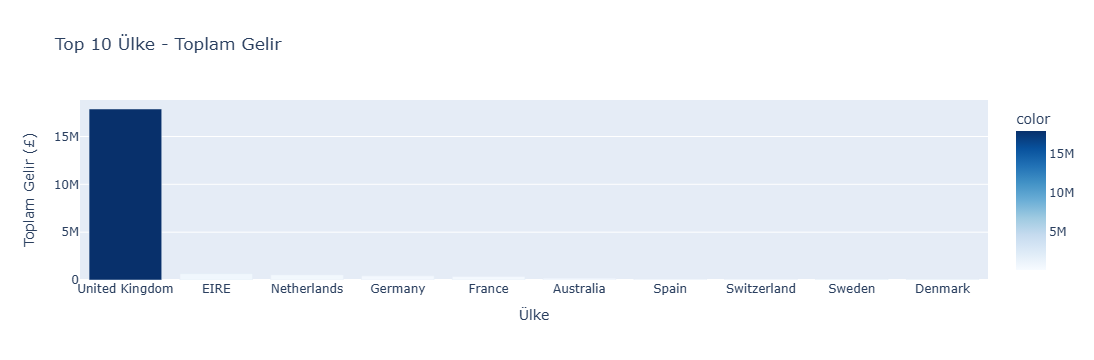

In [8]:
country_revenue = df_clean.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

fig = px.bar(
    x=country_revenue.index,
    y=country_revenue.values,
    title='Top 10 Ülke - Toplam Gelir',
    labels={'x': 'Ülke', 'y': 'Toplam Gelir (£)'},
    color=country_revenue.values,
    color_continuous_scale='Blues'
)
fig.show()

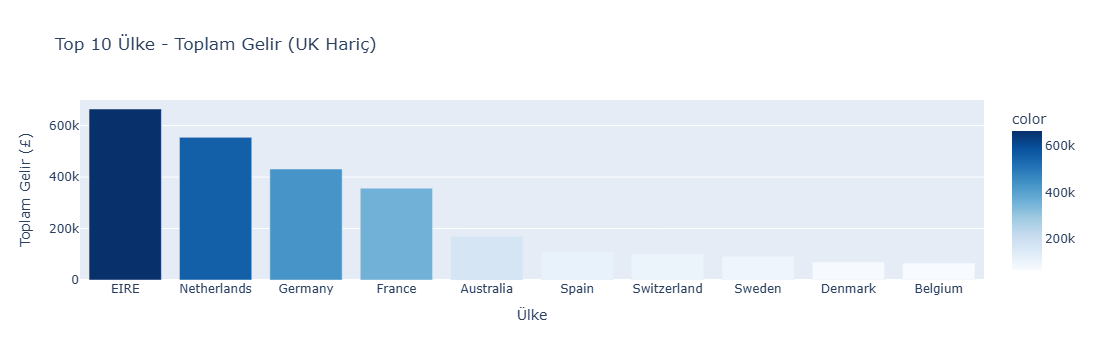

In [9]:
country_revenue_no_uk = df_clean[df_clean['Country'] != 'United Kingdom'].groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

fig = px.bar(
    x=country_revenue_no_uk.index,
    y=country_revenue_no_uk.values,
    title='Top 10 Ülke - Toplam Gelir (UK Hariç)',
    labels={'x': 'Ülke', 'y': 'Toplam Gelir (£)'},
    color=country_revenue_no_uk.values,
    color_continuous_scale='Blues'
)
fig.show()

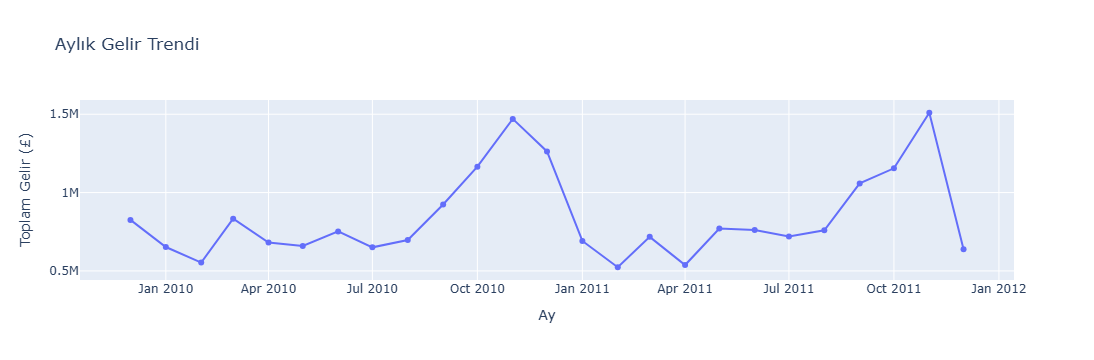

In [10]:
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
monthly_revenue = df_clean.groupby('YearMonth')['TotalPrice'].sum().reset_index()
monthly_revenue['YearMonth'] = monthly_revenue['YearMonth'].astype(str)

fig = px.line(
    monthly_revenue,
    x='YearMonth',
    y='TotalPrice',
    title='Aylık Gelir Trendi',
    labels={'YearMonth': 'Ay', 'TotalPrice': 'Toplam Gelir (£)'},
    markers=True
)
fig.show()

In [11]:
print(df_clean['InvoiceDate'].min())
print(df_clean['InvoiceDate'].max())

2009-12-01 07:45:00
2011-12-09 12:50:00


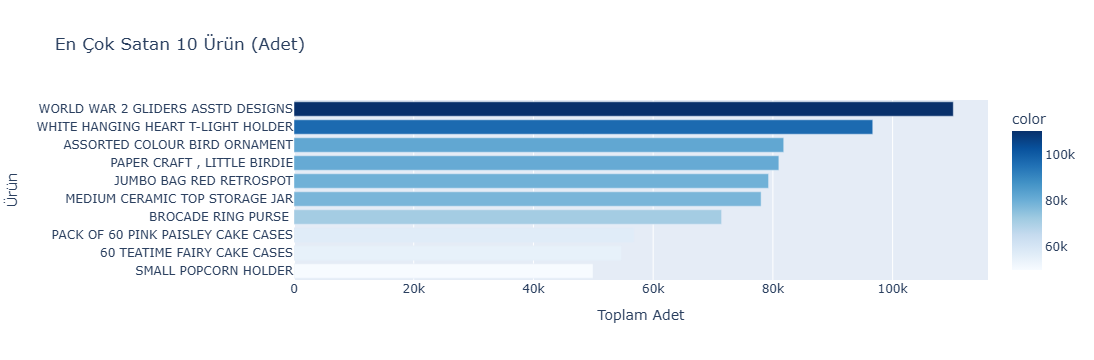

In [12]:
top_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

fig = px.bar(
    x=top_products.values,
    y=top_products.index,
    orientation='h',
    title='En Çok Satan 10 Ürün (Adet)',
    labels={'x': 'Toplam Adet', 'y': 'Ürün'},
    color=top_products.values,
    color_continuous_scale='Blues'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

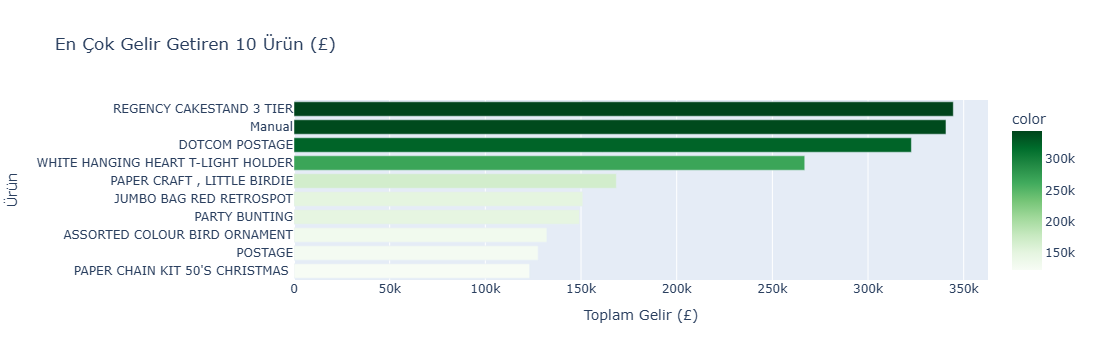

In [13]:
top_products_revenue = df_clean.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

fig = px.bar(
    x=top_products_revenue.values,
    y=top_products_revenue.index,
    orientation='h',
    title='En Çok Gelir Getiren 10 Ürün (£)',
    labels={'x': 'Toplam Gelir (£)', 'y': 'Ürün'},
    color=top_products_revenue.values,
    color_continuous_scale='Greens'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

In [14]:
exclude = ['Manual', 'DOTCOM POSTAGE', 'POSTAGE', 'AMAZONFEE']
df_clean = df_clean[~df_clean['Description'].isin(exclude)]
print(f"Kalan satır sayısı: {len(df_clean)}")

Kalan satır sayısı: 1037467


In [15]:
df_rfm = df_clean.dropna(subset=['Customer ID']).copy()

# Referans tarihi: datasetteki son günden 1 gün sonrası
reference_date = df_rfm['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_rfm.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print(rfm.shape)
print(rfm.head())

(5862, 4)
  Customer ID  Recency  Frequency  Monetary
0       12346      326         12  77556.46
1       12347        2          8   5633.32
2       12348       75          5   1658.40
3       12349       19          3   3678.69
4       12350      310          1    294.40


In [16]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1,2,3,4,5])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print(rfm.head())

  Customer ID  Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score
0       12346      326         12  77556.46       2       5       5       255
1       12347        2          8   5633.32       5       4       5       545
2       12348       75          5   1658.40       3       4       4       344
3       12349       19          3   3678.69       5       3       5       535
4       12350      310          1    294.40       2       1       2       212


In [17]:
def segment_customer(row):
    score = row['RFM_Score']
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'VIP'
    elif r >= 4 and f >= 3:
        return 'Sadık Müşteri'
    elif r >= 4 and f <= 2:
        return 'Yeni Müşteri'
    elif r == 3:
        return 'Potansiyel'
    elif r <= 2 and f >= 3:
        return 'Kaybedilmek Üzere'
    else:
        return 'Kayıp'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)
print(rfm['Segment'].value_counts())

Segment
Kayıp                1515
VIP                  1296
Potansiyel           1156
Kaybedilmek Üzere     830
Sadık Müşteri         615
Yeni Müşteri          450
Name: count, dtype: int64


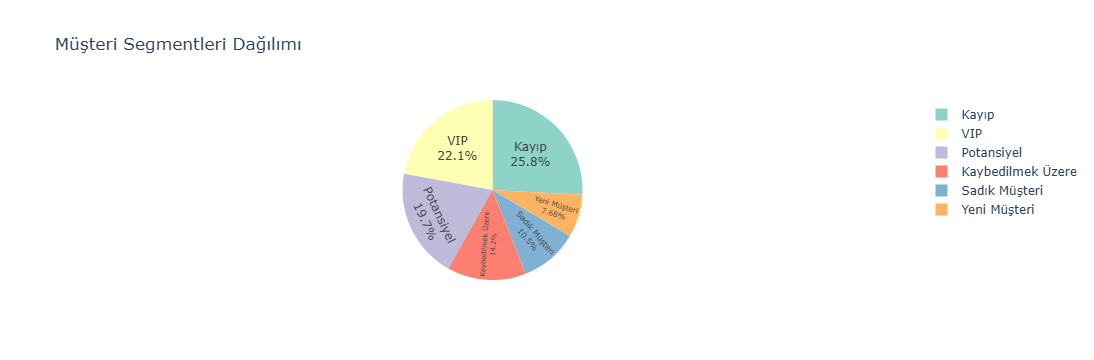

In [18]:
segment_counts = rfm['Segment'].value_counts()

fig = px.pie(
    values=segment_counts.values,
    names=segment_counts.index,
    title='Müşteri Segmentleri Dağılımı',
    color_discrete_sequence=px.colors.qualitative.Set3
)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()